In [1]:
# done with poetry
# %pip install pandas
# %pip install scikit-learn
# %pip install xgboost

In [15]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor

## Data loading

In [3]:
BASE_DIR = os.path.dirname("modules")

In [4]:
module = "../../modules"
data_folder = "data"

df_bu_feat = pd.read_csv(os.path.join(module,data_folder,"bu_feat.csv.gz"))  # this feature should be read as feature store, for now just using remote repo to store it
df_train = pd.read_csv(os.path.join(module, data_folder, "train.csv.gz"))
df_test = pd.read_csv(os.path.join(module, data_folder, "test.csv.gz")) 

### Merging features

In [5]:
df_train_feat = pd.merge(df_train, df_bu_feat, how="left", on = "but_num_business_unit")
df_test_feat = pd.merge(df_test, df_bu_feat, how="left", on = "but_num_business_unit")

### Split train, val set

In [6]:
df_train_feat.head(5)

,day_id,but_num_business_unit,dpt_num_department,turnover,but_postcode,but_latitude,but_longitude,but_region_idr_region,zod_idr_zone_dgr
0,2017-09-30,64,127,580.308443,16400,45.625172,0.111939,70,10
1,2017-09-30,119,127,1512.995918,74100,46.195037,6.254448,51,4
2,2017-09-30,4,88,668.593556,6600,43.600994,7.078160,55,10
3,2017-09-30,425,127,0.000000,59000,50.617921,3.084186,33,3
4,2017-09-30,513,73,0.000000,33610,44.717366,-0.733429,33,3


In [7]:
df_train_feat.shape

(277719, 9)

In [25]:
df_train_feat["day_id"].unique()

array(['2017-09-30', '2017-09-23', '2017-09-16', '2017-09-09',
       '2017-09-02', '2017-08-26', '2017-08-19', '2017-08-12',
       '2017-08-05', '2017-07-29', '2017-07-22', '2017-07-15',
       '2017-07-08', '2017-07-01', '2017-06-24', '2017-06-17',
       '2017-06-10', '2017-06-03', '2017-05-27', '2017-05-20',
       '2017-05-13', '2017-05-06', '2017-04-29', '2017-04-22',
       '2017-04-15', '2017-04-08', '2017-04-01', '2017-03-25',
       '2017-03-18', '2017-03-11', '2017-03-04', '2017-02-25',
       '2017-02-18', '2017-02-11', '2017-02-04', '2017-01-28',
       '2017-01-21', '2017-01-14', '2017-01-07', '2016-12-31',
       '2016-12-24', '2016-12-17', '2016-12-10', '2016-12-03',
       '2016-11-26', '2016-11-19', '2016-11-12', '2016-11-05',
       '2016-10-29', '2016-10-22', '2016-10-15', '2016-10-08',
       '2016-10-01', '2016-09-24', '2016-09-17', '2016-09-10',
       '2016-09-03', '2016-08-27', '2016-08-20', '2016-08-13',
       '2016-08-06', '2016-07-30', '2016-07-23', '2016-

In [8]:
df_train_feat["but_num_business_unit"].unique()

array([  64,  119,    4,  425,  513,  211,   10,  177,   39,  214, 1601,
        381,  652,   31,  507,  773,  131,  187,  249,  522,   11,  461,
        243,  216,  648, 1113,   69,   55, 1120,  812,  199,   18,   61,
        162,    5,   49,   87,  242,   13, 1869,  481,  484,  403,  241,
       1107,  191,   81,  539,   93,  504,  218,  136,  178,  148,   82,
         72,  483,   78,  134, 1887,  610,  212,  721,  152,  308,  753,
        158,  155,  151,  172,  100,  456,  762,   63,  454,    1,  186,
        167,   19,   96,  175,  232,    2,  727,   48,  301, 1875,  477,
         83,  184,   89, 1882,   27,  541,  255,  253,   76,  229,  225,
         25, 1118, 1112,  694, 1116,  353,  405,  482, 1129,  150,  195,
        116,  298, 1607,   53,  348,   29,   34,  357, 1611,  427,  363,
         67, 1122,  254,  109,   42,  693,   38, 1124,  233,    8,  338,
       1881,  282,  641,   70,    9,  394,  396,   54,  115,  496,  779,
         99,  159, 1119, 1409,  426, 1123,   36,  6

In [9]:
df_train_feat["dpt_num_department"].unique()

array([127,  88,  73, 117])

<Axes: >

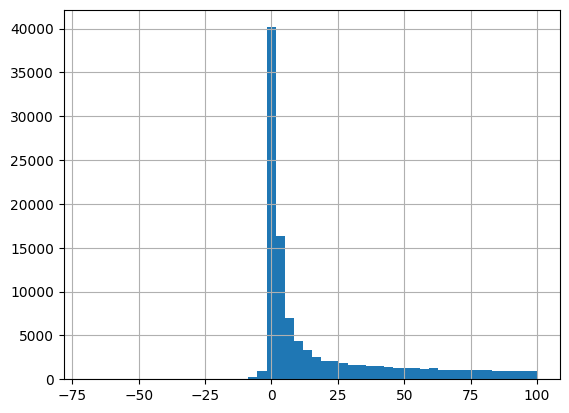

In [18]:
df_train_feat[df_train_feat["turnover"]<100]["turnover"].hist(bins=50)

<Axes: >

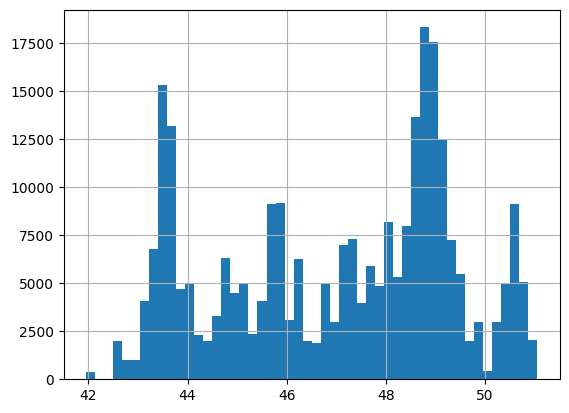

In [20]:
df_train_feat["but_latitude"].hist(bins=50)

<Axes: >

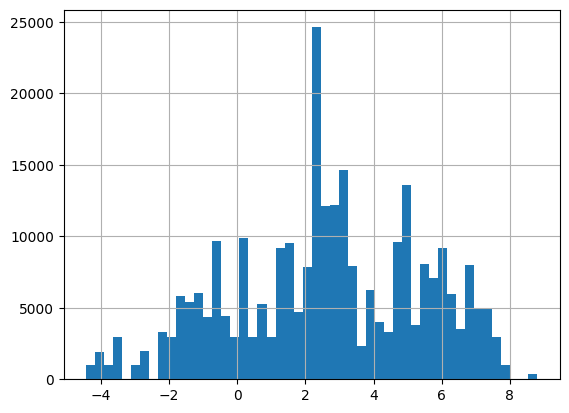

In [21]:
df_train_feat["but_longitude"].hist(bins=50)

<Axes: >

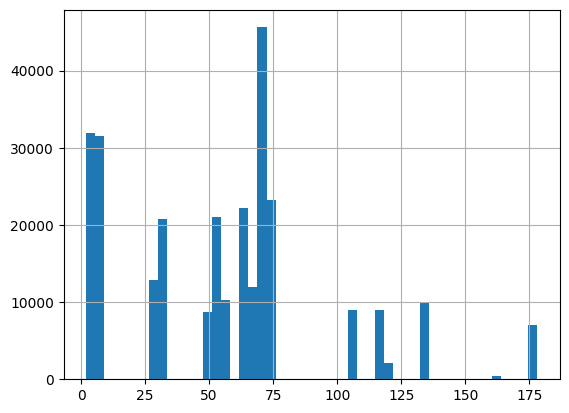

In [23]:
df_train_feat["but_region_idr_region"].hist(bins=50)

<Axes: >

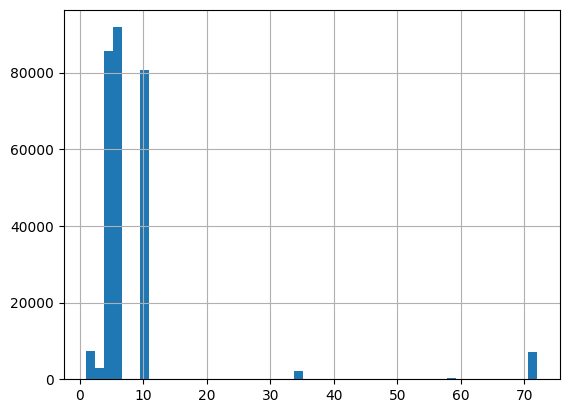

In [24]:
df_train_feat["zod_idr_zone_dgr"].hist(bins=50)

In [ ]:
# Train and val set

df_train_feat["day_id"] = pd.to_datetime(df_train_feat["day_id"])
df_train_feat["day_id_week"] = df_train_feat.day_id.dt.isocalendar().week
df_train_feat["day_id_month"] = df_train_feat["day_id"].dt.month
df_train_feat["day_id_year"] = df_train_feat["day_id"].dt.year

# 2017 must a variable
year_split = 2017
df_train = df_train_feat[(df_train_feat.day_id_year < year_split)] # seems that there is data leackage !
df_val = df_train_feat[(df_train_feat.day_id_year == 2017)]

y_train = df_train.turnover # this as variable config !
y_val = df_val.turnover

### Scikit pipeline

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin

In [17]:
# this is a custom transformer -> dependency alert!
class CustomPreprocressing(BaseEstimator, TransformerMixin):
    """
    This class includes all the steps for the preprocessing
    """
    def __init__(self, cat_cols):
        """
        Initialize the class / Can be empty
        """
        self.cat_cols = cat_cols

    def fit(self, X, y=None):
        """
        This method is only created so that the pipeline containing this transformer does not raise an error
        """
        return self

    def transform(self, data):
        """
        Inputs :
          -- data : DataFrame, DataFrame contening all the data needed for the model
        Outputs :
          -- DataFrame, DataFrame prepared for modeling

        """
        data["day_id"] = pd.to_datetime(data["day_id"])
        data["day_id_week"] = data.day_id.dt.isocalendar().week
        data["day_id_month"] = data["day_id"].dt.month
        data["day_id_year"] = data["day_id"].dt.year
        data[self.cat_cols] = data[self.cat_cols].apply(lambda x: x.astype(str))
        return data

In [18]:

num_attrib = ["but_latitude","but_longitude", 'day_id_year']
cat_attrib = [
            "day_id_week",
            "day_id_month",
            "but_region_idr_region",
            "zod_idr_zone_dgr",
            "but_num_business_unit",
            "dpt_num_department",
        ]

num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])
cat_onehot_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown="ignore")),
])
preparation_pipeline = ColumnTransformer([
    ("num",num_pipeline, num_attrib),
    ("cat_onehot", cat_onehot_pipeline, cat_attrib)
])

full_pipeline = Pipeline([
    ('preprocessing', CustomPreprocressing(cat_cols=cat_attrib )),
    ('preparation', preparation_pipeline),
    ('model', GradientBoostingRegressor())
])

In [19]:
model_final = full_pipeline.fit(df_train, y_train)
y_predict_val = model_final.predict(df_val)

metric_mae = mean_absolute_error(y_val, y_predict_val)
print(metric_mae)

/tmp/ipykernel_15776/524110047.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["day_id"] = pd.to_datetime(data["day_id"])
/tmp/ipykernel_15776/524110047.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["day_id_week"] = data.day_id.dt.isocalendar().week
/tmp/ipykernel_15776/524110047.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

407.2289311686877


/tmp/ipykernel_15776/524110047.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["day_id"] = pd.to_datetime(data["day_id"])
/tmp/ipykernel_15776/524110047.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["day_id_week"] = data.day_id.dt.isocalendar().week
/tmp/ipykernel_15776/524110047.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

In [20]:
df_val['dpt_num_department'].unique()

array(['127', '88', '73', '117'], dtype=object)

In [21]:
df_val['prediction'] = y_predict_val
filter_ts = lambda x: (x.but_num_business_unit=="32") & (x.dpt_num_department=='73')
display(df_val[filter_ts].head(10))

display(df_train[filter_ts].head(10))

/tmp/ipykernel_15776/2715622416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['prediction'] = y_predict_val


,day_id,but_num_business_unit,dpt_num_department,turnover,but_postcode,but_latitude,but_longitude,but_region_idr_region,zod_idr_zone_dgr,day_id_week,day_id_month,day_id_year,prediction
1089,2017-09-30,32,73,452.769296,29490,48.425054,-4.436446,7,6,39,9,2017,469.318872
2519,2017-09-23,32,73,513.263277,29490,48.425054,-4.436446,7,6,38,9,2017,469.318872
3432,2017-09-16,32,73,912.694843,29490,48.425054,-4.436446,7,6,37,9,2017,469.318872
4290,2017-09-09,32,73,831.668945,29490,48.425054,-4.436446,7,6,36,9,2017,469.318872
5599,2017-09-02,32,73,528.774473,29490,48.425054,-4.436446,7,6,35,9,2017,469.318872
6357,2017-08-26,32,73,562.253678,29490,48.425054,-4.436446,7,6,34,8,2017,502.036028
7705,2017-08-19,32,73,898.535514,29490,48.425054,-4.436446,7,6,33,8,2017,502.036028
9811,2017-08-12,32,73,1049.221014,29490,48.425054,-4.436446,7,6,32,8,2017,502.036028
10973,2017-08-05,32,73,1082.103732,29490,48.425054,-4.436446,7,6,31,8,2017,502.036028
12303,2017-07-29,32,73,1155.885670,29490,48.425054,-4.436446,7,6,30,7,2017,502.036028


,day_id,but_num_business_unit,dpt_num_department,turnover,but_postcode,but_latitude,but_longitude,but_region_idr_region,zod_idr_zone_dgr,day_id_week,day_id_month,day_id_year
49581,2016-12-31,32,73,544.941047,29490,48.425054,-4.436446,7,6,52,12,2016
50950,2016-12-24,32,73,1023.650512,29490,48.425054,-4.436446,7,6,51,12,2016
51720,2016-12-17,32,73,1231.944726,29490,48.425054,-4.436446,7,6,50,12,2016
53122,2016-12-10,32,73,657.439375,29490,48.425054,-4.436446,7,6,49,12,2016
54834,2016-12-03,32,73,715.383766,29490,48.425054,-4.436446,7,6,48,12,2016
54920,2016-11-26,32,73,650.073868,29490,48.425054,-4.436446,7,6,47,11,2016
56116,2016-11-19,32,73,827.484007,29490,48.425054,-4.436446,7,6,46,11,2016
58308,2016-11-12,32,73,947.222428,29490,48.425054,-4.436446,7,6,45,11,2016
58821,2016-11-05,32,73,976.114374,29490,48.425054,-4.436446,7,6,44,11,2016
59821,2016-10-29,32,73,967.194617,29490,48.425054,-4.436446,7,6,43,10,2016


In [22]:
model_final = full_pipeline.fit(df_train_feat, df_train_feat.turnover.values)


In [23]:
y_pred = model_final.predict(df_test_feat)

In [24]:
df_test_feat['prediction'] = y_pred

In [25]:
display(df_test_feat.head(10))

,day_id,but_num_business_unit,dpt_num_department,but_postcode,but_latitude,but_longitude,but_region_idr_region,zod_idr_zone_dgr,day_id_week,day_id_month,day_id_year,prediction
0,2017-11-25,95,73,80000,49.869382,2.280452,69,4,47,11,2017,28.096508
1,2017-11-25,4,117,6600,43.600994,7.078160,55,10,47,11,2017,324.086069
2,2017-11-25,113,127,84014,43.919562,4.867583,115,10,47,11,2017,1333.614589
3,2017-11-25,93,117,13008,43.239744,5.396694,71,10,47,11,2017,357.205467
4,2017-11-25,66,127,34500,43.347835,3.255024,6,10,47,11,2017,1389.478844
5,2017-11-25,225,88,91220,48.622942,2.301157,2,6,47,11,2017,499.755396
6,2017-11-25,37,117,6210,43.551454,6.948166,55,10,47,11,2017,324.086069
7,2017-11-25,720,73,22100,48.475374,-2.041166,7,6,47,11,2017,169.660511
8,2017-11-25,1015,127,59000,50.636600,3.069400,32,1,47,11,2017,497.073405
9,2017-11-25,505,88,77183,48.829569,2.636586,2,6,47,11,2017,519.015757
